# Testing
### Bevölkerung nach Stadtquartier, Herkunft, Geschlecht und Alter, seit 1993
Datum: 15.03.2023


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns


In [3]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [4]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [5]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

Zuerst die Zeitvariabeln als Strings

In [6]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
month_today = now.strftime("%m")
day_today = now.strftime("%d")


Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [7]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2025 5 datenstand:  3 time.struct_time(tm_year=2025, tm_mon=5, tm_mday=12, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=0, tm_yday=132, tm_isdst=-1)


Berechne die Variable Epoche um später das SAS-Datum in ein Unix-Datum umzuwandeln. Bei SAS beginnt die Epoche am 1.1.1960. Bei Unix am 1.1.1970.
Diese Variable wird beim CSV-Import benötigt.

In [8]:
epoch = datetime.datetime(1960, 1, 1)

### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

**BITTE HIER ANPASSEN**

In [9]:
package_name = "bev_bestand_jahr_quartier_alter_herkunft_geschlecht_od3903"

In [10]:
dataset_name = "BEV390OD3903.csv"

**Statische Pfade in DWH-Dropzones**

In [11]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"

In [12]:
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"

**Statische Pfade CKAN-URLs**

In [13]:
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"

In [14]:
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [15]:
from IPython.display import Markdown as md

In [16]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_quartier_alter_herkunft_geschlecht_od3903 

In [17]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_alter_herkunft_geschlecht_od3903 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [18]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "prod"; #prod vs something else
data_source = "web"; #dropzone vs something else
print(status+" - "+ data_source)

prod - web


In [19]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_alter_herkunft_geschlecht_od3903/download/BEV390OD3903.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

In [20]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        ,parse_dates=['StichtagDatJahr']
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        ,parse_dates=['StichtagDatJahr']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes

web


StichtagDatJahr    datetime64[ns]
AlterVSort                  int64
AlterVCd                    int64
AlterV05Sort                int64
AlterV05Cd                  int64
AlterV05Kurz               object
AlterV10Cd                  int64
AlterV10Kurz               object
AlterV20Cd                  int64
AlterV20Kurz               object
SexCd                       int64
SexLang                    object
SexKurz                    object
KreisCd                     int64
KreisLang                  object
QuarSort                    int64
QuarCd                      int64
QuarLang                   object
HerkunftSort                int64
HerkunftCd                  int64
HerkunftLang               object
AnzBestWir                  int64
dtype: object

Berechne weitere Attribute falls notwendig

In [21]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
AlterVSort                      int64
AlterVCd                        int64
AlterV05Sort                    int64
AlterV05Cd                      int64
AlterV05Kurz                   object
AlterV10Cd                      int64
AlterV10Kurz                   object
AlterV20Cd                      int64
AlterV20Kurz                   object
SexCd                           int64
SexLang                        object
SexKurz                        object
KreisCd                         int64
KreisLang                      object
QuarSort                        int64
QuarCd                          int64
QuarLang                       object
HerkunftSort                    int64
HerkunftCd                      int64
HerkunftLang                   object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_str                       object
Jahr_nbr                        int32
dtype: objec

Minimales und maximales Jahr im Datensatz

In [22]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


### Einfache Datentests

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [23]:
#data2betested.head(6)

In [24]:
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
AlterVSort                      int64
AlterVCd                        int64
AlterV05Sort                    int64
AlterV05Cd                      int64
AlterV05Kurz                   object
AlterV10Cd                      int64
AlterV10Kurz                   object
AlterV20Cd                      int64
AlterV20Kurz                   object
SexCd                           int64
SexLang                        object
SexKurz                        object
KreisCd                         int64
KreisLang                      object
QuarSort                        int64
QuarCd                          int64
QuarLang                       object
HerkunftSort                    int64
HerkunftCd                      int64
HerkunftLang                   object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_str                       object
Jahr_nbr                        int32
dtype: objec

In [25]:
data2betested.shape

(395968, 26)

Beschreibe einzelne Attribute

In [26]:
data2betested.describe()

,StichtagDatJahr,AlterVSort,AlterVCd,AlterV05Sort,AlterV05Cd,AlterV10Cd,AlterV20Cd,...,QuarSort,QuarCd,HerkunftSort,HerkunftCd,AnzBestWir,Jahr,Jahr_nbr
count,395968,395968,395968,395968,395968,395968,395968,...,395968,395968,395968,395968,395968,395968,395968
mean,2008-08-19 12:24:45.501859072,47,47,10,45,42,37,...,66,66,1,1,32,2008-08-19 12:24:45.501859072,2009
min,1993-01-01 00:00:00,0,0,1,0,0,0,...,11,11,1,1,0,1993-01-01 00:00:00,1993
25%,2001-01-01 00:00:00,23,23,5,20,20,20,...,34,34,1,1,7,2001-01-01 00:00:00,2001
50%,2009-01-01 00:00:00,46,46,10,45,40,40,...,71,71,1,1,21,2009-01-01 00:00:00,2009
75%,2017-01-01 00:00:00,69,69,14,65,60,60,...,92,92,2,2,45,2017-01-01 00:00:00,2017
max,2024-01-01 00:00:00,111,111,21,100,100,100,...,123,123,2,2,266,2024-01-01 00:00:00,2024
std,NaN,27,27,5,27,27,27,...,35,35,0,0,33,NaN,9


Wie viele Nullwerte gibt es im Datensatz?

In [27]:
data2betested.isnull().sum()

StichtagDatJahr        0
AlterVSort             0
AlterVCd               0
AlterV05Sort           0
AlterV05Cd             0
AlterV05Kurz           0
AlterV10Cd             0
AlterV10Kurz           0
AlterV20Cd             0
AlterV20Kurz           0
SexCd                  0
SexLang                0
SexKurz                0
KreisCd                0
KreisLang              0
QuarSort               0
QuarCd                 0
QuarLang               0
HerkunftSort           0
HerkunftCd             0
HerkunftLang           0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_str               0
Jahr_nbr               0
dtype: int64

Welches sind die Quartiere ohne Werte bei AnzBestWir?

In [28]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,AlterVSort,AlterVCd,AlterV05Sort,AlterV05Cd,AlterV05Kurz,AlterV10Cd,...,HerkunftCd,HerkunftLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_str,Jahr_nbr


In [29]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 395,968 rows (observations) and 26 columns (variables).
There seem to be 0 exact duplicates in the data.


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [30]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [31]:
data2betested.info()
data2betested.index.year.unique()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 395968 entries, 1993-01-01 to 2024-01-01
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   AlterVSort           395968 non-null  int64         
 1   AlterVCd             395968 non-null  int64         
 2   AlterV05Sort         395968 non-null  int64         
 3   AlterV05Cd           395968 non-null  int64         
 4   AlterV05Kurz         395968 non-null  object        
 5   AlterV10Cd           395968 non-null  int64         
 6   AlterV10Kurz         395968 non-null  object        
 7   AlterV20Cd           395968 non-null  int64         
 8   AlterV20Kurz         395968 non-null  object        
 9   SexCd                395968 non-null  int64         
 10  SexLang              395968 non-null  object        
 11  SexKurz              395968 non-null  object        
 12  KreisCd              395968 non-null  int64         
 13

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [32]:
#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [33]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,AlterVSort,AlterVCd,AlterV05Sort,AlterV05Cd,AlterV05Kurz,AlterV10Cd,AlterV10Kurz,...,HerkunftCd,HerkunftLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_str,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,
2024-01-01,0,0,1,0,0-4,0,0-9,...,2,Ausländer*in,37,2024-01-01,2024-01-01,2024-01-01,2024
2024-01-01,0,0,1,0,0-4,0,0-9,...,2,Ausländer*in,39,2024-01-01,2024-01-01,2024-01-01,2024


### Visualisierungen nach Zeitausschnitten

In [48]:
data2betested.columns

Index(['AlterVSort', 'AlterVCd', 'AlterV05Sort', 'AlterV05Cd', 'AlterV05Kurz', 'AlterV10Cd',
       'AlterV10Kurz', 'AlterV20Cd', 'AlterV20Kurz', 'SexCd', 'SexLang', 'SexKurz', 'KreisCd',
       'KreisLang', 'QuarSort', 'QuarCd', 'QuarLang', 'HerkunftSort', 'HerkunftCd', 'HerkunftLang',
       'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_str', 'Jahr_nbr'],
      dtype='object')

In [51]:
#Anfrage: Anzahl 65-jähriger Personen
#, 'AlterV05Sort','AlterV05Kurz'

myAgg65Plus = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=False) 

myAgg65Plus.reset_index().head(10)

,StichtagDatJahr,sum_WBev
0,2024-01-01,448664
1,2023-01-01,447082
2,2022-01-01,443037
3,2021-01-01,436332
4,2020-01-01,434736
5,2019-01-01,434008
6,2018-01-01,428737
7,2017-01-01,423310
8,2016-01-01,415682
9,2015-01-01,410404


#### Entwicklung Wohnbevölkerung nach Altersgruppe

In [52]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterV05Kurz']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg.reset_index().head(3)

,StichtagDatJahr,AlterV05Kurz,sum_WBev
0,1993-01-01,0-4,15637
1,1993-01-01,95-99,381
2,1993-01-01,90-94,2111


In [53]:
myTitle="Wohnbevölkerung nach Altersgruppe, "+data_min_date+" - "+data_max_date

highlight = alt.selection(type='single', on='mouseover',
                          fields=['AlterV05Kurz'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>300'), title=myTitle).encode(
    x=alt.X('StichtagDatJahr', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('AlterV05Kurz', legend=alt.Legend(title="Altersgruppen", orient="right"))  
    ,tooltip=['StichtagDatJahr', 'AlterV05Kurz','sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=750 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Entwicklung nach Herkunft

In [54]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,HerkunftLang,sum_WBev
0,1993-01-01,Ausländer*in,96857
1,1993-01-01,Schweizer*in,264041
2,1994-01-01,Ausländer*in,99298


In [55]:
myTitle="Wohnbevölkerung nach Herkunft, "+data_min_date+" - "+data_max_date

highlight = alt.selection(type='single', on='mouseover',
                          fields=['HerkunftLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg2.reset_index().query('sum_WBev>300'), title=myTitle).encode(
    x=alt.X('StichtagDatJahr', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('HerkunftLang', legend=alt.Legend(title="Herkunft", orient="right"))  
    ,tooltip=['StichtagDatJahr', 'HerkunftLang','sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=750 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [56]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterV05Sort','AlterV05Kurz', 'HerkunftLang', 'HerkunftCd']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAggBar.reset_index().head(3)

,StichtagDatJahr,AlterV05Sort,AlterV05Kurz,HerkunftLang,HerkunftCd,sum_WBev
0,2024-01-01,1,0-4,Ausländer*in,2,6425
1,2024-01-01,12,55-59,Schweizer*in,1,18854
2,2024-01-01,13,60-64,Ausländer*in,2,4537


In [57]:
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")

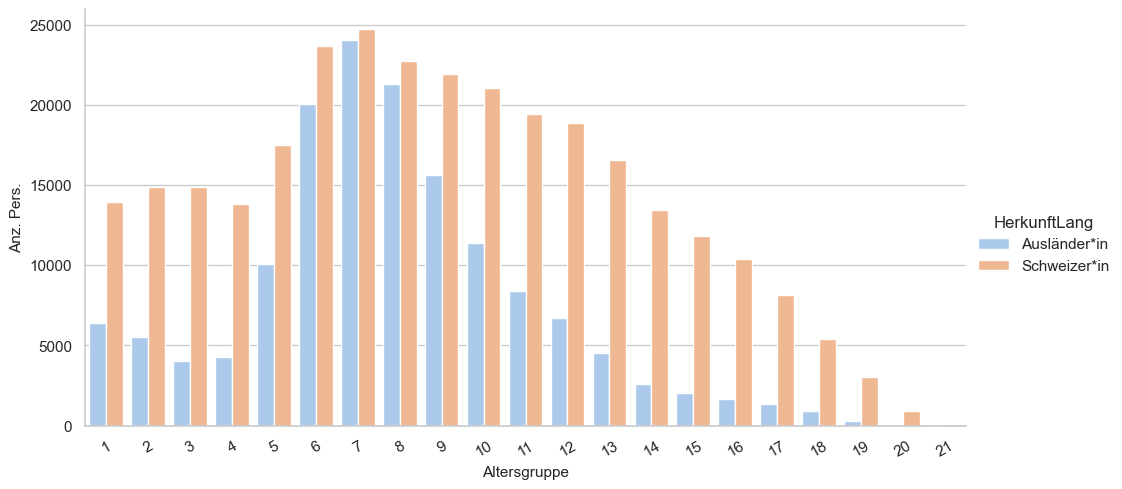

In [58]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="AlterV05Sort"
            , y="sum_WBev"
            , hue="HerkunftLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


##### Facet Grids: Bevölkerung nach Herkunft/Geschlecht und Alter, nach Quartier, 2022

In [59]:
myAggBar = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterVSort','AlterVKurz', 'HerkunftLang', 'HerkunftCd', 'QuarLang', 'QuarSort']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('QuarSort', ascending=True) 

KeyError: 'AlterVKurz'

In [ ]:
myAggBar2 = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterVSort','AlterVKurz', 'SexKurz', 'SexCd', 'QuarLang', 'QuarSort']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('QuarSort', ascending=True) 

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWar

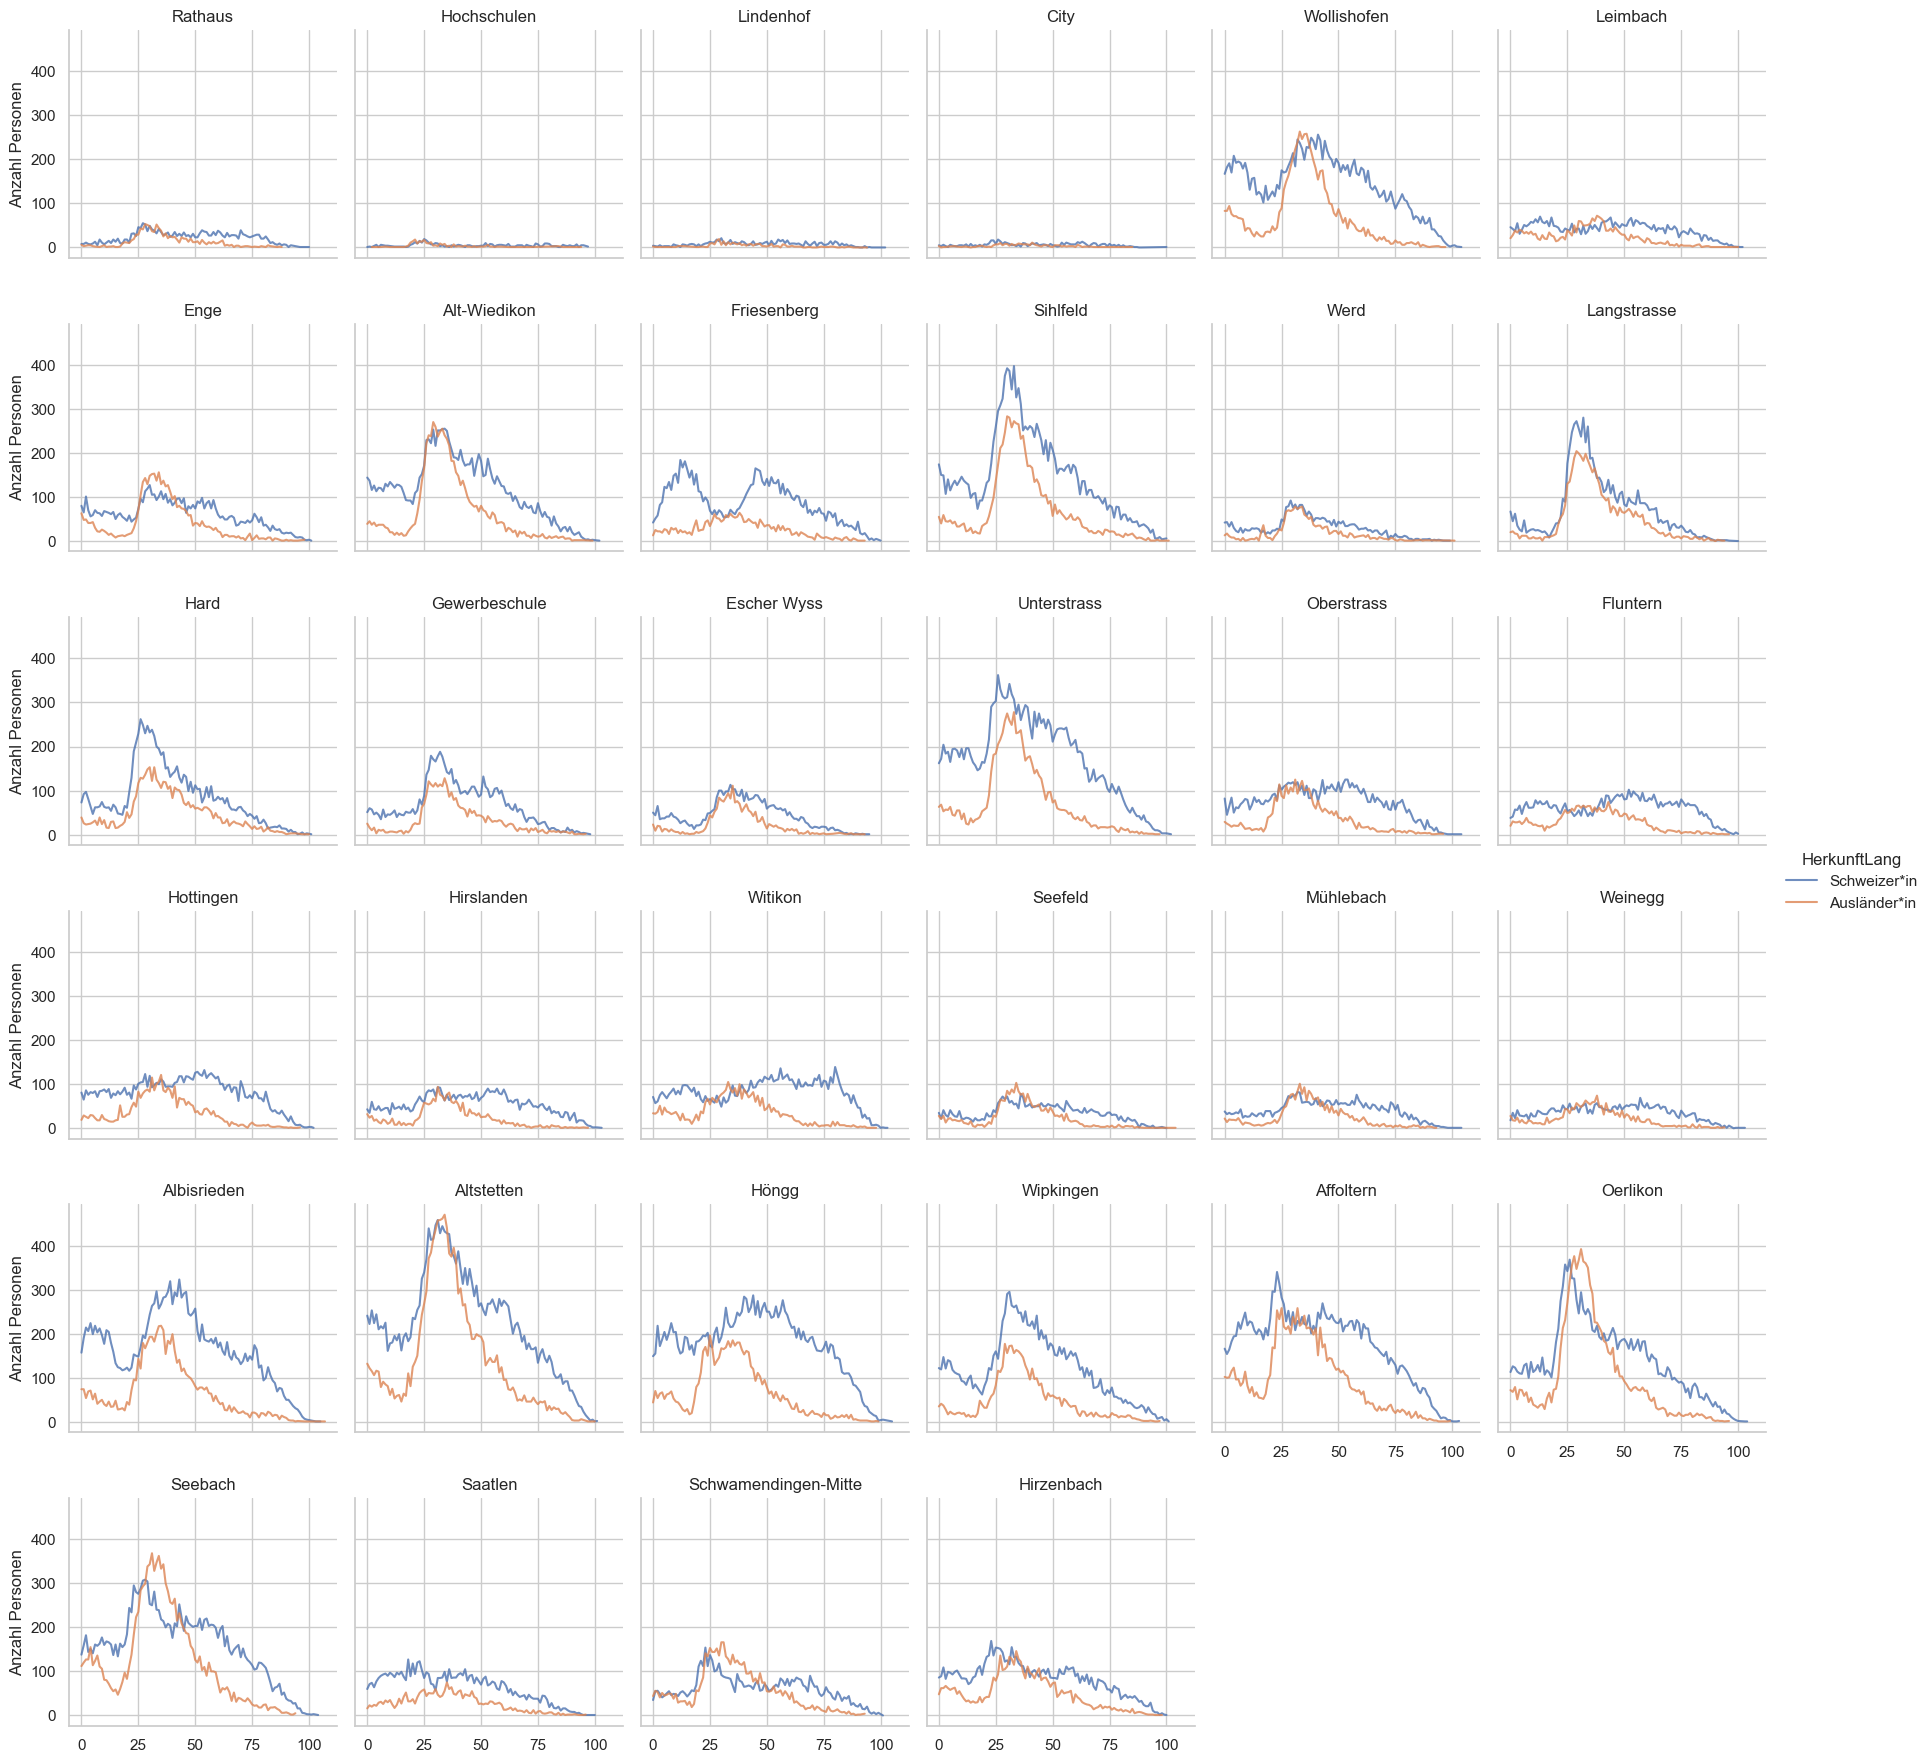

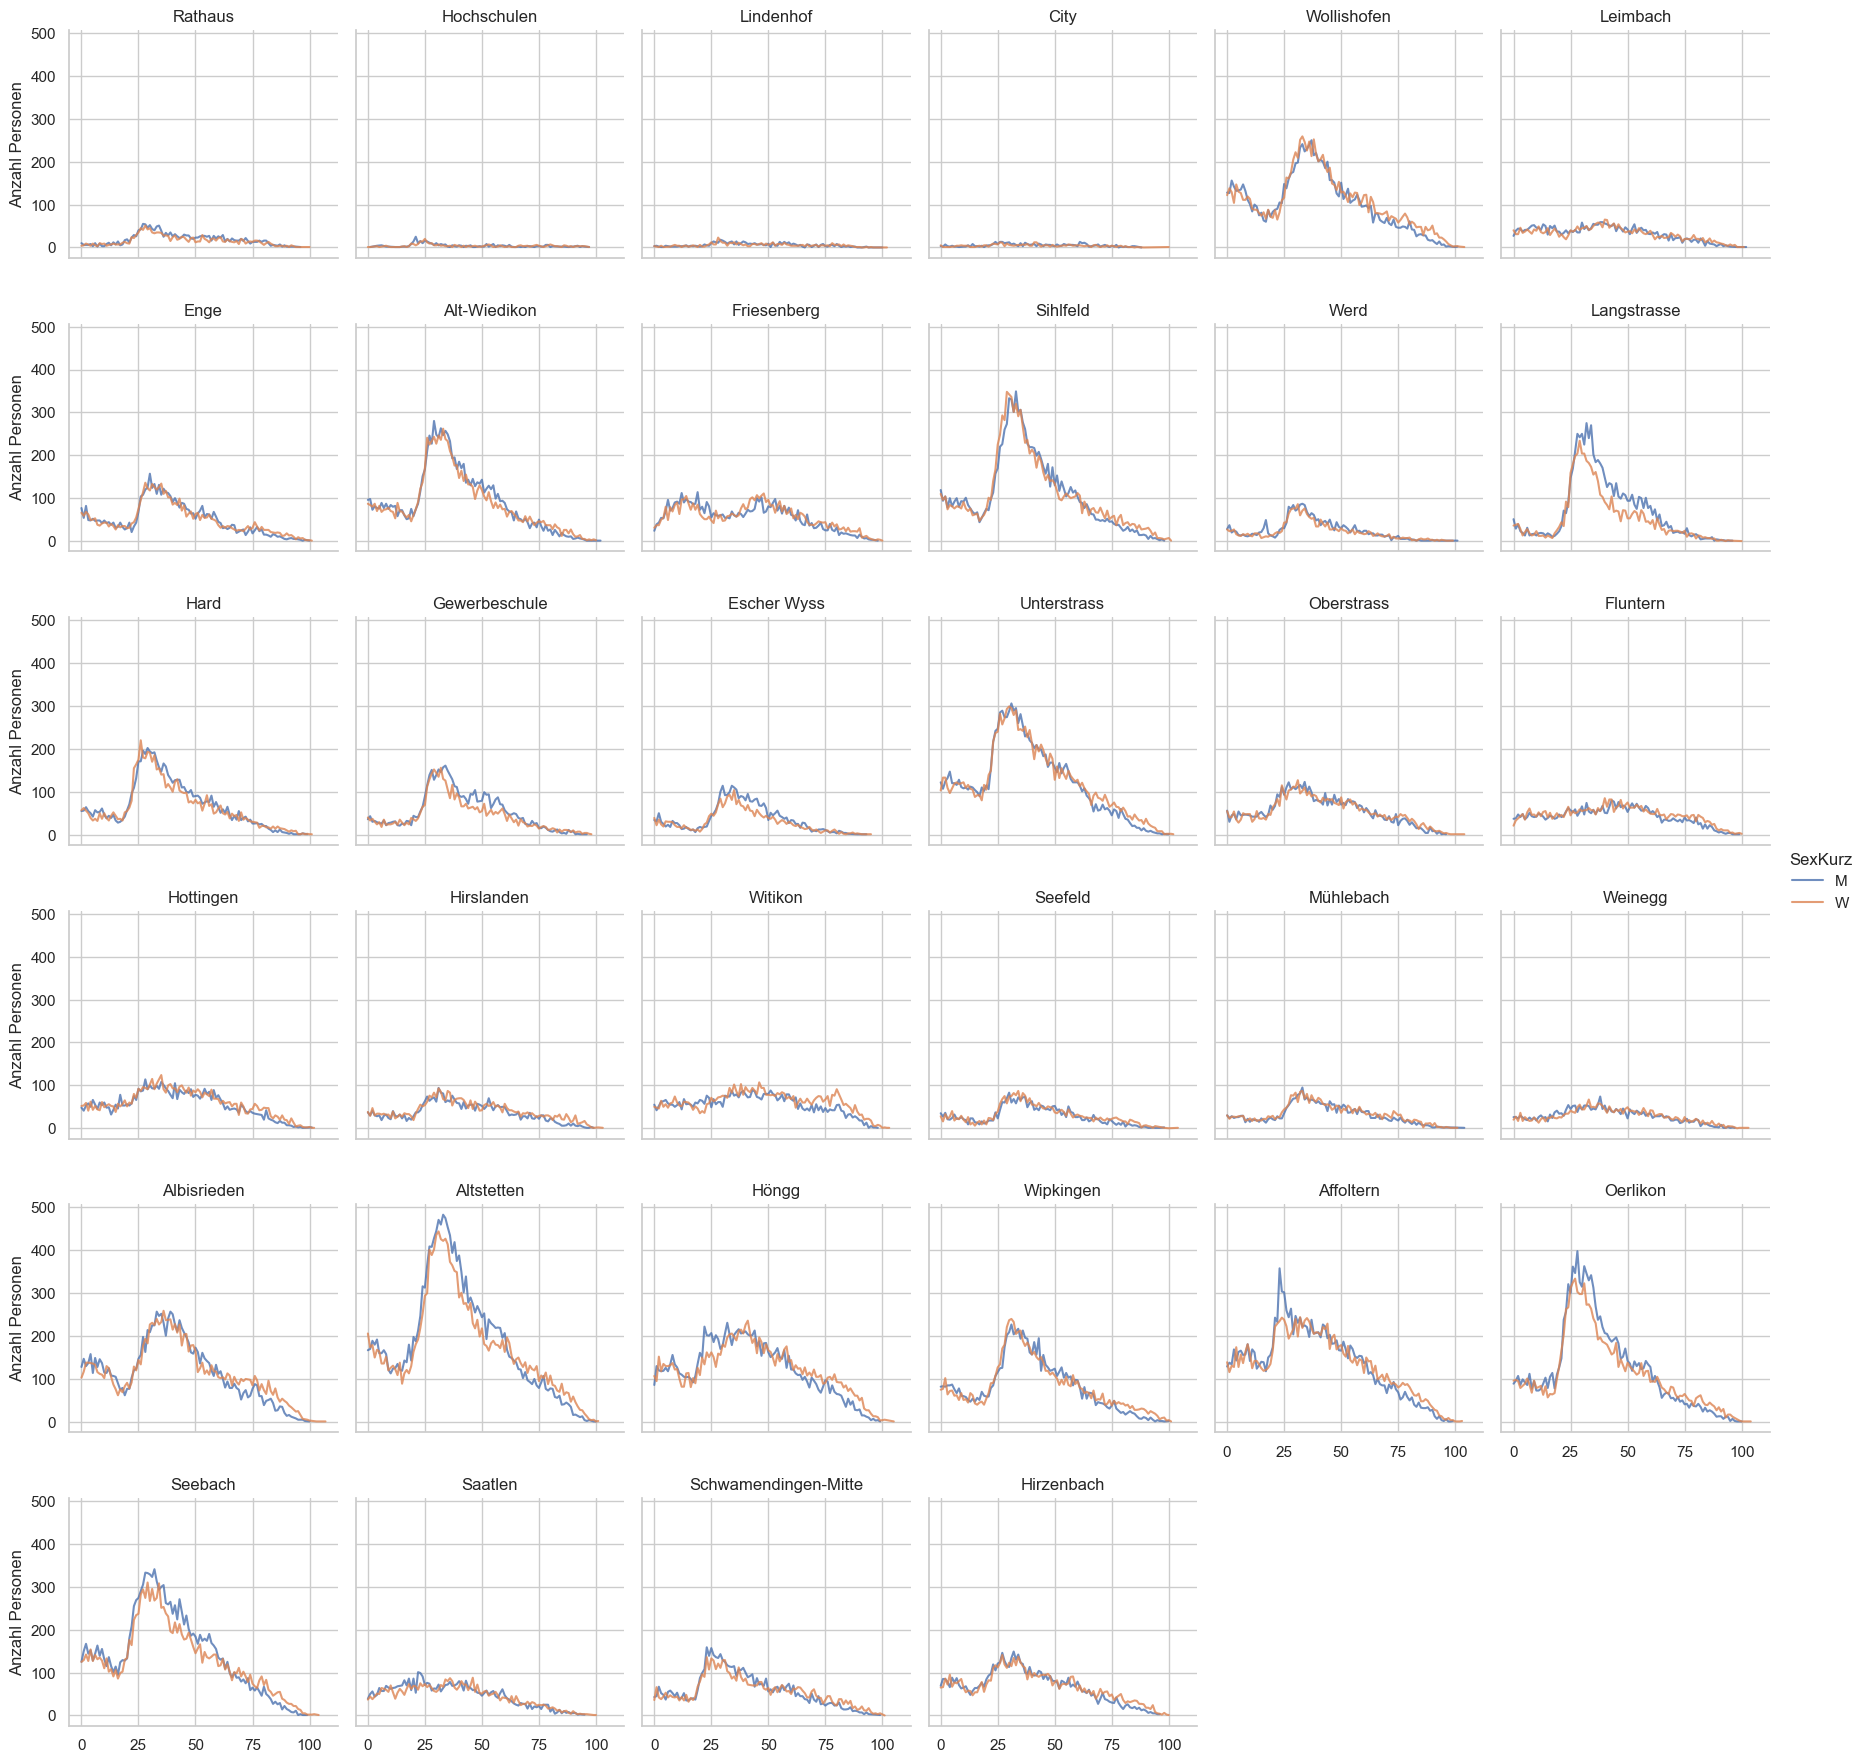

In [ ]:
#g = sns.FacetGrid(myAggBar.reset_index(), col="QuarLang", hue="HerkunftLang", col_wrap=6, height=3,)
#g.map(sns.scatterplot, "AlterV05Sort", "sum_WBev", alpha=.8)
#g.add_legend()

g2 = sns.FacetGrid(myAggBar.reset_index(), col="QuarLang", hue="HerkunftLang", col_wrap=6, height=3,)
g2.map(sns.lineplot, "AlterVSort","sum_WBev",alpha=.8)

g2.set_axis_labels("","Anzahl Personen")
g2.set_titles(col_template="{col_name}", row_template="{row_name}")

g2.add_legend()

g3 = sns.FacetGrid(myAggBar2.reset_index(), col="QuarLang", hue="SexKurz", col_wrap=6, height=3,)
g3.map(sns.lineplot, "AlterVSort","sum_WBev",alpha=.8)

g3.set_axis_labels("","Anzahl Personen")
g3.set_titles(col_template="{col_name}", row_template="{row_name}")

g3.add_legend()

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Aktueller Bestand der WBev nach Quartier, Herkunft und Geschlecht

In [ ]:
data2betested.columns

Index(['AlterVSort', 'AlterVCd', 'AlterVKurz', 'AlterV05Sort', 'AlterV05Cd', 'AlterV05Kurz',
       'AlterV10Cd', 'AlterV10Kurz', 'AlterV20Cd', 'AlterV20Kurz', 'SexCd', 'SexLang', 'SexKurz',
       'KreisCd', 'KreisLang', 'QuarSort', 'QuarCd', 'QuarLang', 'HerkunftSort', 'HerkunftCd',
       'HerkunftLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_str', 'Jahr_nbr'],
      dtype='object')

In [ ]:
myTreemapAgg = data2betested.loc[data_max_date]  \
    .groupby(['StichtagDatJahr', 'QuarLang', 'HerkunftLang', 'SexKurz']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=True) 

myTreemapAgg.reset_index().head(3)

,StichtagDatJahr,QuarLang,HerkunftLang,SexKurz,sum_WBev
0,2023-01-01,Hochschulen,Ausländer*in,W,97
1,2023-01-01,City,Ausländer*in,W,114
2,2023-01-01,Lindenhof,Ausländer*in,W,129


In [ ]:
myTitle = "WBev nach Quartier, Herkunft und Geschlecht, "+data_max_date

fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant(myTitle), 'QuarLang', 'HerkunftLang', 'SexKurz']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='Blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 ,height=400
                 ,width=1100                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

#### Aktueller Bestand der WBev nach Quartier und Herkunft

In [ ]:
#data2betested.columns

In [ ]:
myTreemapAgg = data2betested.loc[data_max_date]  \
    .groupby(['StichtagDatJahr', 'QuarLang', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=True) 

myTreemapAgg.reset_index().head(3)

,StichtagDatJahr,QuarLang,HerkunftLang,sum_WBev
0,2023-01-01,Hochschulen,Ausländer*in,246
1,2023-01-01,City,Ausländer*in,254
2,2023-01-01,Lindenhof,Ausländer*in,294


In [ ]:
myTitle = "WBev nach Quartier und Herkunft, "+data_max_date

fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant(myTitle), 'StichtagDatJahr', 'QuarLang', 'HerkunftLang']
                 , values='sum_WBev'
                 , color='HerkunftLang'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'Ausländer/in':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }         
                 , color_discrete_map={'(?)':'lightgrey','Schweizer/in':'gold', 'SP':'#FF3030' }               
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])   
                 ,height=400
                 ,width=1100
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

In [ ]:
#data2betested.dtypes

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=115&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

#### Stadtkreise

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_kreise = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_stadtkreise_v"
adm_stadtkreise_v = gpd.read_file(geojson_url_kreise)

adm_stadtkreise_v.head(1)


,id,kname,knr,objid,geometry
0,adm_stadtkreise_v.1,Kreis 6,6,1,"POLYGON ((8.52602 47.40844, 8.52625 47.40855, ..."


#### Statistische Zonen

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_statzonen = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Zonen?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statzonen_map"
adm_statzonen_map = gpd.read_file(geojson_url_statzonen)

adm_statzonen_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,stzname,stznr,geometry
0,adm_statzonen_map.1,Kreis 7,7,1,154,Hirslanden,73,Hegibach,7303,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statzonen_map.2,Kreis 7,7,2,89,Hirslanden,73,Klus,7302,"POLYGON ((8.57281 47.35806, 8.57278 47.35807, ..."


#### Statistische Quartiere

In [ ]:
geojson_url_quartiere = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url_quartiere)

df_adm_statistische_quartiere_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."


### Teste LeafMap

Mehr Infos: https://leafmap.org/leafmap/

In [ ]:
m = leafmap.Map()

#m.add_geojson(geojson_url_kreise, layer_name="adm_stadtkreise_v", fill_colors=['red', 'yellow', 'green', 'orange'], info_mode=True)
m.add_gdf(df_adm_statistische_quartiere_map, layer_name='adm_statistische_quartiere_map', style={}, hover_style={}, style_callback=None, fill_colors=['black'], info_mode='on_hover', zoom_to_layer=True)
m.add_gdf(adm_stadtkreise_v, layer_name='adm_stadtkreise_v', style={}, hover_style={}, style_callback=None, fill_colors=['none'], info_mode='on_hover', zoom_to_layer=False)

m.add_legend(title='Legende', legend_dict=None, labels=None, colors=None, position='bottomright', builtin_legend=None, layer_name='adm_statistische_quartiere_map')
m

NameError: name 'leafmap' is not defined

### Joins
Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [ ]:
#data2betested.dtypes
data2betested.head()

,QuarSort,QuarCd,QuarLang,AlterVSort,AlterVCd,AlterVKurz,AlterV05Sort,AlterV05Kurz,HerkunftLang,HerkunftCd,HerkunftSort,SexCd,SexKurz,AnzBestWir
StichtagDatJahr,,,,,,,,,,,,,,
1993-01-01,11,11,Rathaus,0,0,0,1,0-4,Schweizer/in,1,1,1,M,11
1993-01-01,11,11,Rathaus,0,0,0,1,0-4,Schweizer/in,1,1,2,W,8
1993-01-01,11,11,Rathaus,0,0,0,1,0-4,Ausländer/in,2,2,1,M,1
1993-01-01,11,11,Rathaus,0,0,0,1,0-4,Ausländer/in,2,2,2,W,6
1993-01-01,11,11,Rathaus,1,1,1,1,0-4,Schweizer/in,1,1,1,M,11


In [ ]:
myAgg = data2betested.loc["2020"]  \
    .copy() \
    .groupby(['QuarLang', 'QuarCd']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .assign() \
    .sort_values('QuarCd', ascending=False) 

#myAgg.reset_index()


In [ ]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
gdf_adm_statistische_quartiere_map = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})
gdf_adm_statistische_quartiere_map.head(1)

,geometry,QuarCd,qname,knr
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7


#### Leftjoin 
Matche die statistischen Daten mit den Geodaten

In [ ]:
# Merge with `merge` method on shared variable (stznr und StatZoneSort):
gdf_adm_statistische_quartiere_map_joined = gdf_adm_statistische_quartiere_map.merge(myAgg, on='QuarCd', how="left") #'right', 'inner', 'left'
gdf_adm_statistische_quartiere_map_joined.head(2)


,geometry,QuarCd,qname,knr,sum_AnzBestWir
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,7396
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,5562


In [ ]:
#does all match?
gdf_adm_statistische_quartiere_map_joined.isnull().sum()

geometry          0
QuarCd            0
qname             0
knr               0
sum_AnzBestWir    0
dtype: int64

<AxesSubplot:>

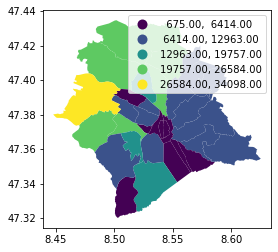

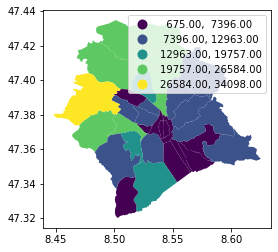

In [ ]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_AnzBestWir', cmap='viridis', scheme='natural_breaks', legend=True )
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_AnzBestWir', cmap='viridis', scheme='fisherjenks', legend=True )

#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

<AxesSubplot:>

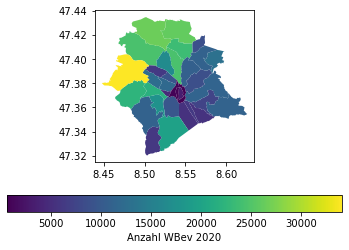

In [ ]:
fig, ax = plt.subplots(1, 1)

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_AnzBestWir', ax=ax, legend=True, legend_kwds={'label': "Anzahl WBev 2020",'orientation': "horizontal"})
#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_AnzBestWir', ax=ax, legend=False, legend_kwds={'label': "Anzahl WBev 2020",'orientation': "horizontal"})

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True , ax=ax, legend_kwds={'label': "Anzahl Personen",'orientation': "horizontal"})

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=115&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**